# Setup and conventions

In [1]:
import torch
import torch.nn as nn
from spd_learn.functional import covariance
import pymanopt
import numpy as np
from src.data.dataset_config import DATASET_CONFIG
from src.Visualization.topomap import plot_topomap, plot_pannel
from src.Permutation.FeaturePermutationEEG import FeaturePermutationEEG, DeepFeaturePermutationEEG
from pyriemann.classification import MDM, TSClassifier
from pyriemann.utils.mean import mean_riemann
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from moabb.paradigms import FilterBankMotorImagery
from moabb.datasets import BNCI2014_001, Dreyer2023C, Beetl2021_A
from sklearn.model_selection import train_test_split

from functools import partial
import math
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
np.random.seed(3)

In [3]:
PROJECT_DIR = Path.cwd()
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
PRECOMPUTED_RESULTS_DIR = PROJECT_DIR.parent / "Code" / "Results"
DATA_DIR = f"{FIGURES_DIR}/"  # Kept as a string for plotting helpers.

# Permutation Feature Importance

## EEG version

### Tabular Data

To illustrate PFI, we generate controlled synthetic EEG-like data. The two classes have identical marginal activity for features 7 and 11 but opposite covariance between these channels. Neither channel is sufficient on its own: the classifier must use their interaction. The signal-to-noise ratio is chosen to keep classification informative without making it perfect.

In [4]:
rng = np.random.default_rng(3)

n_trials = 100
n_channels = 22
n_times = 250
sfreq = 250

y_toy = np.repeat([0, 1], n_trials // 2)
X_toy = rng.standard_normal((n_trials, n_channels, n_times))

time = np.arange(n_times) / sfreq
phases = rng.uniform(0, 2 * np.pi, size=n_trials)
shared_mu_rhythm = np.sin(
    2 * np.pi * 10 * time[None, :] + phases[:, None]
)

special_index = 7
special_index_2 = 11

signal_amplitude = 0.4
X_toy[:, special_index, :] += signal_amplitude * shared_mu_rhythm
X_toy[:, special_index_2, :] += (
    signal_amplitude
    * (1 - 2 * y_toy[:, None])
    * shared_mu_rhythm
)



In [5]:
from sklearn.pipeline import Pipeline
pipeline_mdm = Pipeline([
        ('cov', Covariances(),),
        ('clf', MDM())]
    )

Calling directly FeaturePermutationEEG() as it is made for fitting it to a single dataset and is not made for cases with multiple subjects.

In [6]:
perm = FeaturePermutationEEG()

# We do n_perm permutations on n_splits splits
#We give a pipeline that transforms the data into SPD matrices (with Covariances) and then classifies them (with a MDM).
#perm.fit is going to train the model on n_splits splits and compute its importance values
perm.fit(X_toy, y_toy, n_splits = 5, n_perm = 5, pipeline = pipeline_mdm)

#We can print computed importances, of shape (n_splits, n_features) with importance_
#We also have access to accuracies (one per split)
print(perm.importance_)
print(perm.accuracy_)

[[-5.00000000e-02 -3.00000000e-02 -1.30000000e-01 -3.00000000e-02
  -4.00000000e-02 -4.00000000e-02 -5.00000000e-02  2.70000000e-01
  -6.00000000e-02 -3.00000000e-02 -4.00000000e-02  2.30000000e-01
  -7.00000000e-02 -6.00000000e-02  0.00000000e+00 -6.00000000e-02
  -4.00000000e-02 -5.00000000e-02 -7.00000000e-02 -8.00000000e-02
  -2.00000000e-02 -7.00000000e-02]
 [ 7.00000000e-02  2.00000000e-02 -1.00000000e-02 -4.00000000e-02
  -4.00000000e-02 -9.00000000e-02  0.00000000e+00  1.30000000e-01
  -1.00000000e-02 -3.00000000e-02 -8.00000000e-02  1.80000000e-01
   4.00000000e-02 -2.00000000e-02 -4.00000000e-02  1.00000000e-02
  -1.00000000e-02  4.00000000e-02 -2.00000000e-02 -8.00000000e-02
  -3.00000000e-02  4.00000000e-02]
 [ 4.00000000e-02  4.00000000e-02  0.00000000e+00  6.00000000e-02
   4.00000000e-02 -2.00000000e-02  0.00000000e+00  1.70000000e-01
  -3.00000000e-02  0.00000000e+00  2.00000000e-02  1.90000000e-01
   1.00000000e-01 -1.00000000e-02  4.00000000e-02 -5.00000000e-02
   3.0

In [7]:
#If we already have a pretrained pipeline, we can pass it with the pipeline_pretrained parameter. We only given test data for the PFI
#n_splits is not used here since no training is done inside FeaturePermutationEEG

perm_trained = FeaturePermutationEEG()

X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
            X_toy, y_toy, stratify=y_toy, random_state=1, test_size=0.2
        )

pipeline_pretrained = Pipeline([
        ('cov', Covariances(),),
        ('clf', MDM())]
    )
pipeline_pretrained.fit(X_train_toy,y_train_toy)


perm_trained.fit(X_test_toy, y_test_toy, n_perm = 5, pipeline_pretrained = pipeline_pretrained)
print(perm_trained.importance_)
print(perm_trained.accuracy_)

[[ 0.02  0.01  0.01 -0.01 -0.01 -0.08 -0.03  0.15  0.   -0.06 -0.09  0.13
   0.03 -0.03 -0.01  0.03  0.03  0.05  0.03 -0.09 -0.02  0.01]]
[0.55]


### Moabb data

We can also convert and use moabb datasets. For this, we use the load_from_moabb function that either takes a dataset's name if it is among BNCI2014_001, Dreyer2023C or Beetl2021_A. Else, it takes a dataset object. It returns a dict that associates the data X and its labels to each subject.

In [8]:
from src.data.moabb_adapter import load_from_moabb
from src.Permutation.multi_subjects import compute_pfi_eeg_for_subjects

In [9]:
#data is a dict where each subject is associated to its (X,y) tuple 
data_eeg, sensors = load_from_moabb("BNCI2014_001")
print(data_eeg.keys())

dict_keys(['Subject 1', 'Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9'])


To compute PFI for multiple subjects, we call `compute_pfi_eeg_for_subjects`. It takes a dictionary of the form `{"subject_name": (X, y), ...}`.
It returns a dict with the subject names then importance of size (n_splits, n_channels) and accuracy of size (n_splits) for each subject

In [10]:
results_eeg = compute_pfi_eeg_for_subjects(data_eeg, n_splits=2, n_perm=10, pipeline=pipeline_mdm, n_jobs=-1)

Calculating importance for Subject 1...
Calculating importance for Subject 2...
Calculating importance for Subject 3...
Calculating importance for Subject 4...
Calculating importance for Subject 5...
Calculating importance for Subject 6...
Calculating importance for Subject 7...
Calculating importance for Subject 8...
Calculating importance for Subject 9...


Example of how to access the importance of subject 1 : 

In [11]:
importances_subject_1 = results_eeg['Subject 1']["importance"]
print(importances_subject_1)

[[-1.03448276e-02 -4.65517241e-02 -3.27586207e-02 -1.72413793e-02
   3.44827586e-02  0.00000000e+00  0.00000000e+00  2.75862069e-01
   3.44827586e-02 -1.72413793e-02  1.89655172e-01  1.37931034e-01
   5.17241379e-02  2.75862069e-02  4.48275862e-02  0.00000000e+00
   0.00000000e+00  1.72413793e-03  2.56896552e-01 -2.93103448e-02
  -1.55172414e-02 -8.62068966e-03]
 [-1.11022302e-16 -2.41379310e-02  6.89655172e-03 -1.11022302e-16
   1.03448276e-01  3.44827586e-02  4.82758621e-02  3.10344828e-01
   2.67241379e-01  1.89655172e-02  1.72413793e-01  1.55172414e-01
   1.20689655e-01  1.18965517e-01  2.81034483e-01 -1.11022302e-16
   5.68965517e-02  8.62068966e-02  2.58620690e-01 -1.20689655e-02
  -1.11022302e-16 -1.11022302e-16]]


We can visualize these importances thanks to plot_topomap. 

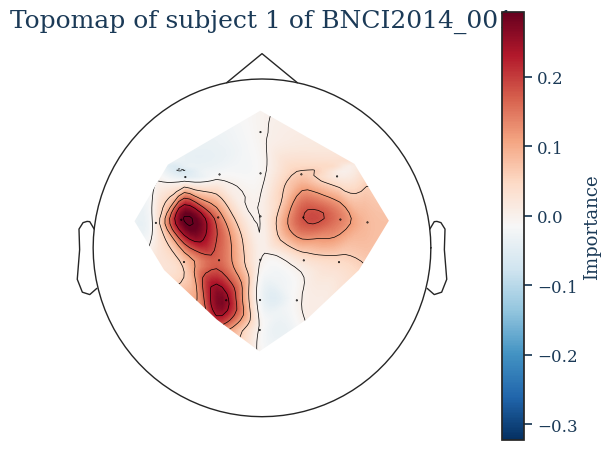

In [12]:
#Takes in input an array of size (n_features), the sensors, the title and other by default parameters
#cbar_type is Shapley by default and defined the colors and labels of the color bar
#savefile_name is None by default
plot_topomap(np.mean(importances_subject_1, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1.pdf')

If we group the results together, we can plot the topomaps for all subjects, along with their accuracies

In [13]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_eeg[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_eeg[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

In [14]:
print(importances_all_subjects.shape)
print(scores_all_subjects.shape)

(9, 22)
(9,)


In [15]:
print(scores_all_subjects)

[0.8362069  0.49137931 0.88793103 0.68965517 0.54310345 0.69827586
 0.68965517 0.94827586 0.77586207]


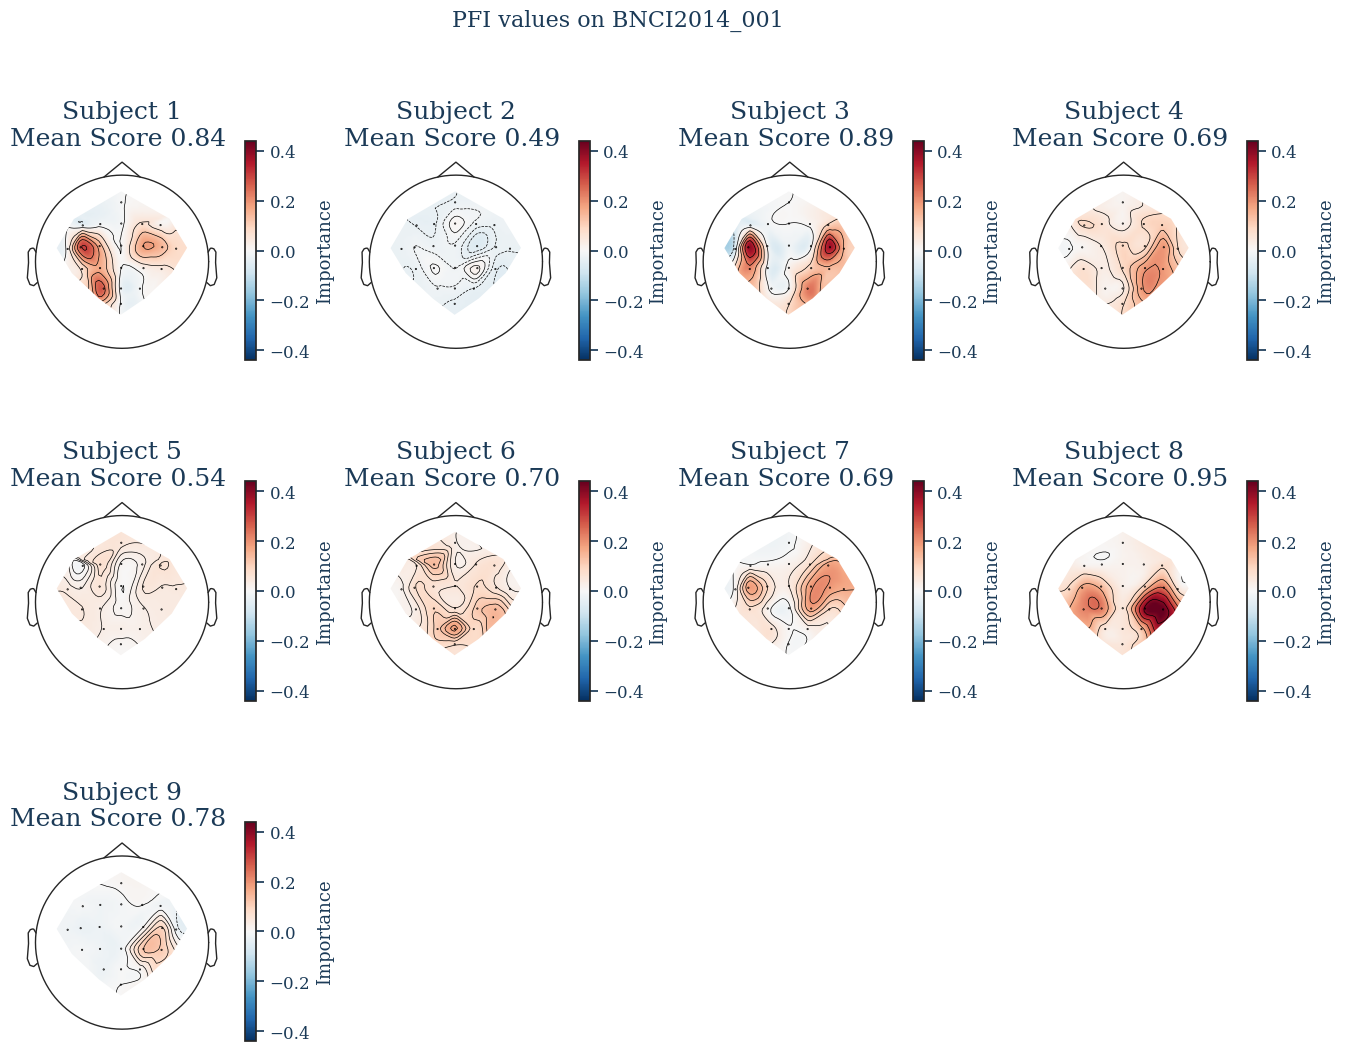

In [16]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_eeg.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects.pdf')

Using a deep model: an example with SPDNet. Either you process a single dataset with `DeepFeaturePermutationEEG`, or you pass a dictionary mapping each subject to a dataset to `compute_deep_pfi_eeg_for_subjects`. As with the non-deep version, you can either pass a pre-trained model via `model_trained`—in which case the function expects input tensors—or provide the model configuration (`model_config`) and type (`model_type`), in which case the function handles the conversion automatically and expects NumPy data. Below, I demonstrate the use of this method with the SPDNet used in the paper.

In [17]:
from spd_learn.modules import BiMap, CovLayer, LogEig, ReEig, SPDBatchNormMeanVar

class SPDNetBatchNorm(nn.Module):

    def __init__(
        self,
        input_type="raw",
        cov_method=covariance,
        subspacedim=None,
        threshold=1e-4,
        upper=True,
        n_chans=None,
        n_outputs=None,
        bn = None
    ):
        super().__init__()

        if subspacedim is None:
            warn(
                "subspacedim is None, using the default value of "
                "the number of channels",
                UserWarning,
            )
            subspacedim = n_chans

        if input_type == "raw":
            self.cov = CovLayer(method=cov_method)
        elif input_type == "cov":
            self.cov = nn.Identity()

        self.bimap = BiMap(n_chans, subspacedim)
        self.bn = bn
        self.reeig = ReEig(threshold)
        self.logeig = LogEig(upper=upper)
        self.len_last_layer = (
            subspacedim * (subspacedim + 1) // 2 if upper else subspacedim**2
        )
        self.classifier = nn.Linear(self.len_last_layer, n_outputs)

    def forward(self, X: torch.Tensor) -> torch.Tensor:

        X = self.cov(X)
        X = self.bimap(X)
        if self.bn is not None:
            X = self.bn(X)
        X = self.reeig(X)
        X = self.logeig(X)
        X = self.classifier(X)

        return X


In [18]:
deep_perm = DeepFeaturePermutationEEG()

In [19]:
from src.Permutation.multi_subjects import compute_deep_pfi_eeg_for_subjects

model_config = {
    "n_chans": data_eeg["Subject 1"][0].shape[1],
    "n_outputs": 2,
    "subspacedim": 16, 
    "bn" : None
}

results_eeg_deep = compute_deep_pfi_eeg_for_subjects(data_eeg, n_splits=10, n_perm=10, model_config=model_config, model_type=SPDNetBatchNorm, n_jobs=1)

Calculating importance for Subject 1...


/home/omille/miniconda3/envs/StageM2/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 10/200 - Loss: 0.6903 - Test Acc: 0.6379
Epoch 20/200 - Loss: 0.6696 - Test Acc: 0.6897
Epoch 30/200 - Loss: 0.6481 - Test Acc: 0.7414
Epoch 40/200 - Loss: 0.6258 - Test Acc: 0.8966
Epoch 50/200 - Loss: 0.6043 - Test Acc: 0.8621
Epoch 60/200 - Loss: 0.5838 - Test Acc: 0.8966
Epoch 70/200 - Loss: 0.5643 - Test Acc: 0.8966
Epoch 80/200 - Loss: 0.5457 - Test Acc: 0.8966
Epoch 90/200 - Loss: 0.5281 - Test Acc: 0.8966
Epoch 100/200 - Loss: 0.5112 - Test Acc: 0.8966
Epoch 110/200 - Loss: 0.4950 - Test Acc: 0.8966
Epoch 120/200 - Loss: 0.4795 - Test Acc: 0.8966
Epoch 130/200 - Loss: 0.4648 - Test Acc: 0.8966
Epoch 140/200 - Loss: 0.4509 - Test Acc: 0.8966
Epoch 150/200 - Loss: 0.4378 - Test Acc: 0.8966
Epoch 160/200 - Loss: 0.4255 - Test Acc: 0.8966
Epoch 170/200 - Loss: 0.4138 - Test Acc: 0.8966
Epoch 180/200 - Loss: 0.4028 - Test Acc: 0.8793
Epoch 190/200 - Loss: 0.3923 - Test Acc: 0.8793
Epoch 200/200 - Loss: 0.3824 - Test Acc: 0.8793
Epoch 10/200 - Loss: 0.6630 - Test Acc: 0.7241
Ep

Results_dic has the same shape has the non deep version and we can visualize topomaps in the same way

In [20]:
importances_subject_1_deep = results_eeg_deep["Subject 1"]["importance"]

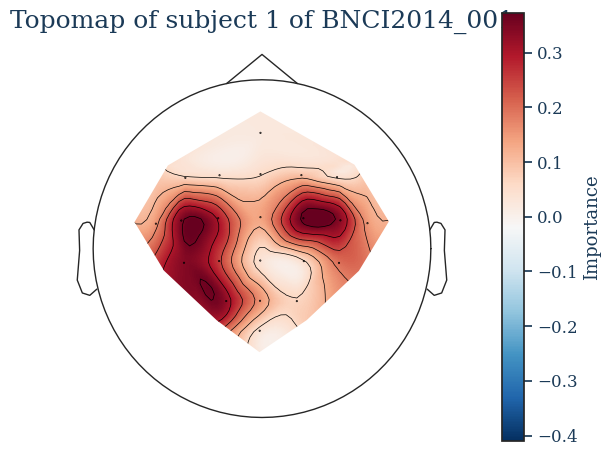

In [21]:
plot_topomap(np.mean(importances_subject_1_deep, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1_deep.pdf')

In [22]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_eeg_deep[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_eeg_deep[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

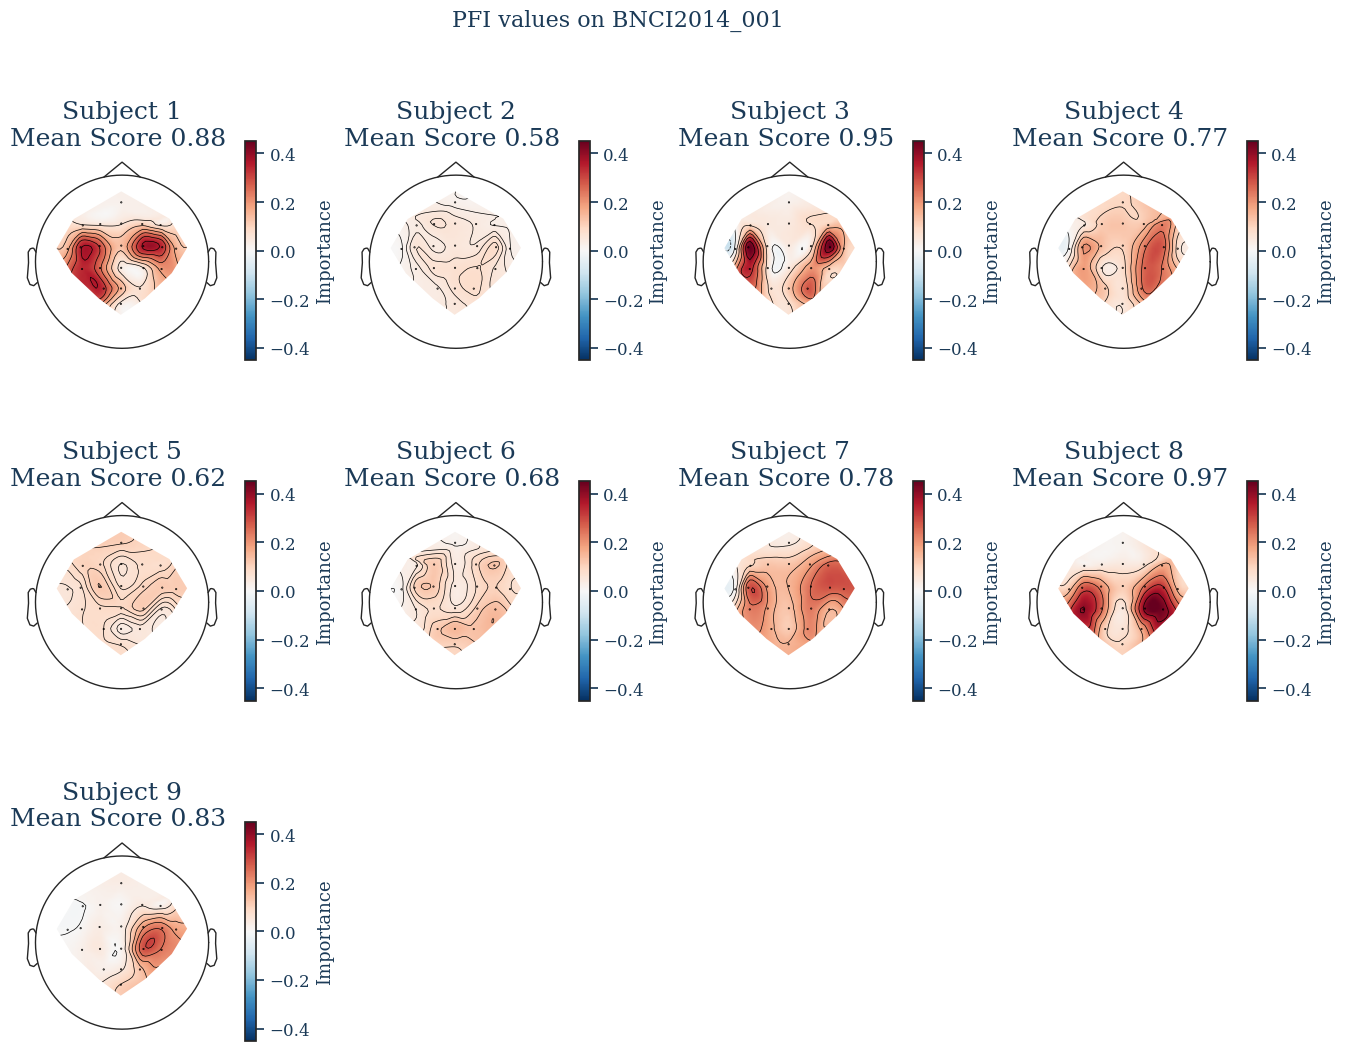

In [23]:
#Plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_eeg.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects_PFI_SPD_SPDNet.pdf')

To reproduce the topomaps for high performing subjects we can use split_subjects_by_score, that takes a results_dic and returns a list of names of high performing and low performing subjects. By default the threshold to be considered a high accuracy subjects is set at 0.75 but it can be passed as a parameter. Then, stack_subjects_by_field groups all subjects' accuracies or importances (depending on the field chosen) whose names are in the array passed in subject_names in a single array. If there were multiple splits, this function also fuses the different splits.

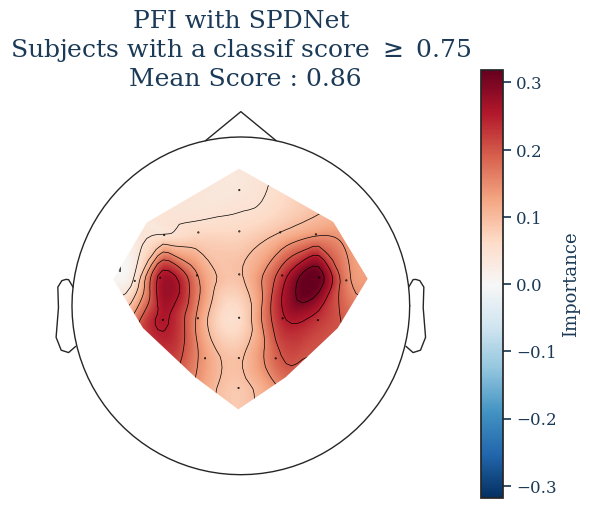

In [24]:
from src.data.utils import split_subjects_by_score, stack_subjects_by_field
high, low = split_subjects_by_score(results_eeg_deep)
importance_HP_subjects = stack_subjects_by_field(results_eeg_deep, high, field = "importance")
accuracy_HP_subjects = stack_subjects_by_field(results_eeg_deep, subject_names = high, field = "accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"PFI with SPDNet\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects.pdf',
            cbar_type = "Permutation")


## SPD version

### Tabular data

In [25]:
from src.Permutation.FeaturePermutationSPD import FeaturePermutationSPD, DeepFeaturePermutationSPD

In [26]:
covs = Covariances()
Covs_matrices = covs.fit_transform(X_toy)
perm_spd = FeaturePermutationSPD()
perm_spd.fit(Covs_matrices, y_toy)

In [27]:
print(perm_spd.importance_)

[[-0.05  0.   -0.15 -0.05 -0.05 -0.05 -0.05  0.25 -0.1   0.    0.    0.25
  -0.05 -0.1   0.   -0.05  0.    0.   -0.05 -0.1   0.   -0.1 ]
 [ 0.05  0.1   0.05  0.    0.   -0.15  0.    0.15  0.   -0.05  0.    0.2
   0.05  0.   -0.05  0.    0.    0.05  0.   -0.15  0.    0.05]
 [ 0.    0.05  0.05  0.05  0.05 -0.05  0.    0.15 -0.05 -0.05 -0.05  0.2
   0.05  0.05  0.1   0.   -0.05  0.1   0.05  0.    0.05  0.  ]
 [-0.1  -0.05 -0.05 -0.05  0.05 -0.1  -0.05  0.1  -0.1  -0.15 -0.05  0.15
   0.   -0.15  0.    0.   -0.1   0.   -0.1  -0.05 -0.05  0.05]
 [ 0.   -0.2  -0.05 -0.15  0.   -0.25  0.05  0.05 -0.1  -0.1  -0.05  0.2
  -0.05 -0.1  -0.15 -0.05 -0.1  -0.1  -0.05 -0.15 -0.1  -0.15]
 [ 0.05  0.05  0.    0.    0.    0.05  0.    0.25  0.    0.05  0.    0.35
   0.05  0.    0.    0.    0.15  0.05  0.    0.    0.05  0.  ]
 [ 0.   -0.05 -0.15 -0.1  -0.05 -0.2   0.   -0.1  -0.1  -0.1  -0.15  0.1
   0.   -0.05 -0.05 -0.05 -0.1  -0.1  -0.05 -0.05 -0.2  -0.05]
 [ 0.1  -0.05  0.    0.05  0.05 -0.1   0.    

### Moabb data

To extract covariances from the moabb data, we use load_from_moabb with the parameter covs set to True

In [28]:
data_spd, sensors = load_from_moabb("BNCI2014_001", covs=True)

In [29]:
print(data_spd["Subject 1"][0].shape)

(288, 22, 22)


`compute_pfi_spd_for_subjects` computes permutation feature importance on SPD matrices for multiple subjects at once. It works similarly to `compute_pfi_eeg_for_subjects`.

In [30]:
from src.Permutation.multi_subjects import compute_pfi_spd_for_subjects
results_spd = compute_pfi_spd_for_subjects(data_spd, n_splits=10, classifier=MDM)

Calculating importance for Subject 1...
Calculating importance for Subject 2...
Calculating importance for Subject 3...
Calculating importance for Subject 4...
Calculating importance for Subject 5...
Calculating importance for Subject 6...
Calculating importance for Subject 7...
Calculating importance for Subject 8...
Calculating importance for Subject 9...


In [32]:
importances_subject_1 = results_spd['Subject 1']["importance"]
print(importances_subject_1)

[[ 0.         -0.05172414 -0.03448276 -0.01724138  0.03448276  0.
   0.          0.27586207  0.03448276 -0.01724138  0.18965517  0.13793103
   0.05172414  0.03448276  0.05172414  0.          0.          0.
   0.25862069 -0.03448276 -0.01724138 -0.01724138]
 [ 0.         -0.03448276  0.          0.          0.10344828  0.03448276
   0.05172414  0.31034483  0.27586207  0.01724138  0.17241379  0.15517241
   0.12068966  0.12068966  0.27586207  0.          0.05172414  0.0862069
   0.25862069 -0.01724138  0.          0.        ]
 [ 0.          0.01724138  0.          0.          0.         -0.01724138
   0.13793103  0.29310345  0.0862069  -0.01724138  0.24137931  0.20689655
   0.03448276  0.10344828  0.24137931 -0.01724138  0.          0.05172414
   0.20689655  0.03448276 -0.03448276  0.        ]
 [ 0.01724138  0.05172414  0.03448276  0.01724138  0.0862069   0.01724138
   0.0862069   0.31034483  0.20689655  0.          0.24137931  0.17241379
   0.0862069   0.18965517  0.25862069  0.01724138 

The way to plot the results does not change between SPD and EEG methods

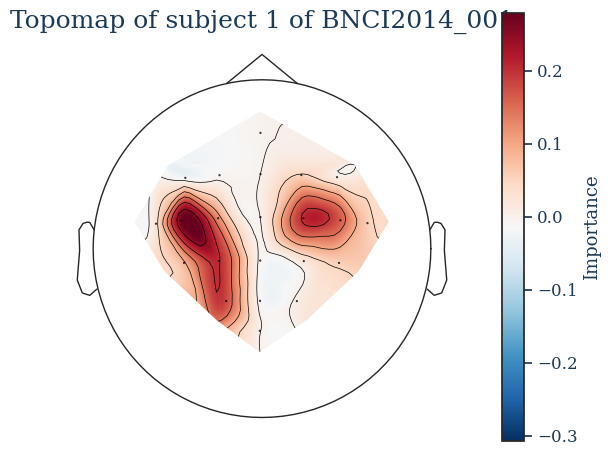

In [33]:
plot_topomap(np.mean(importances_subject_1, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1.pdf')

In [34]:
importances_all_subjects = np.array([np.mean(results_spd[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_spd[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

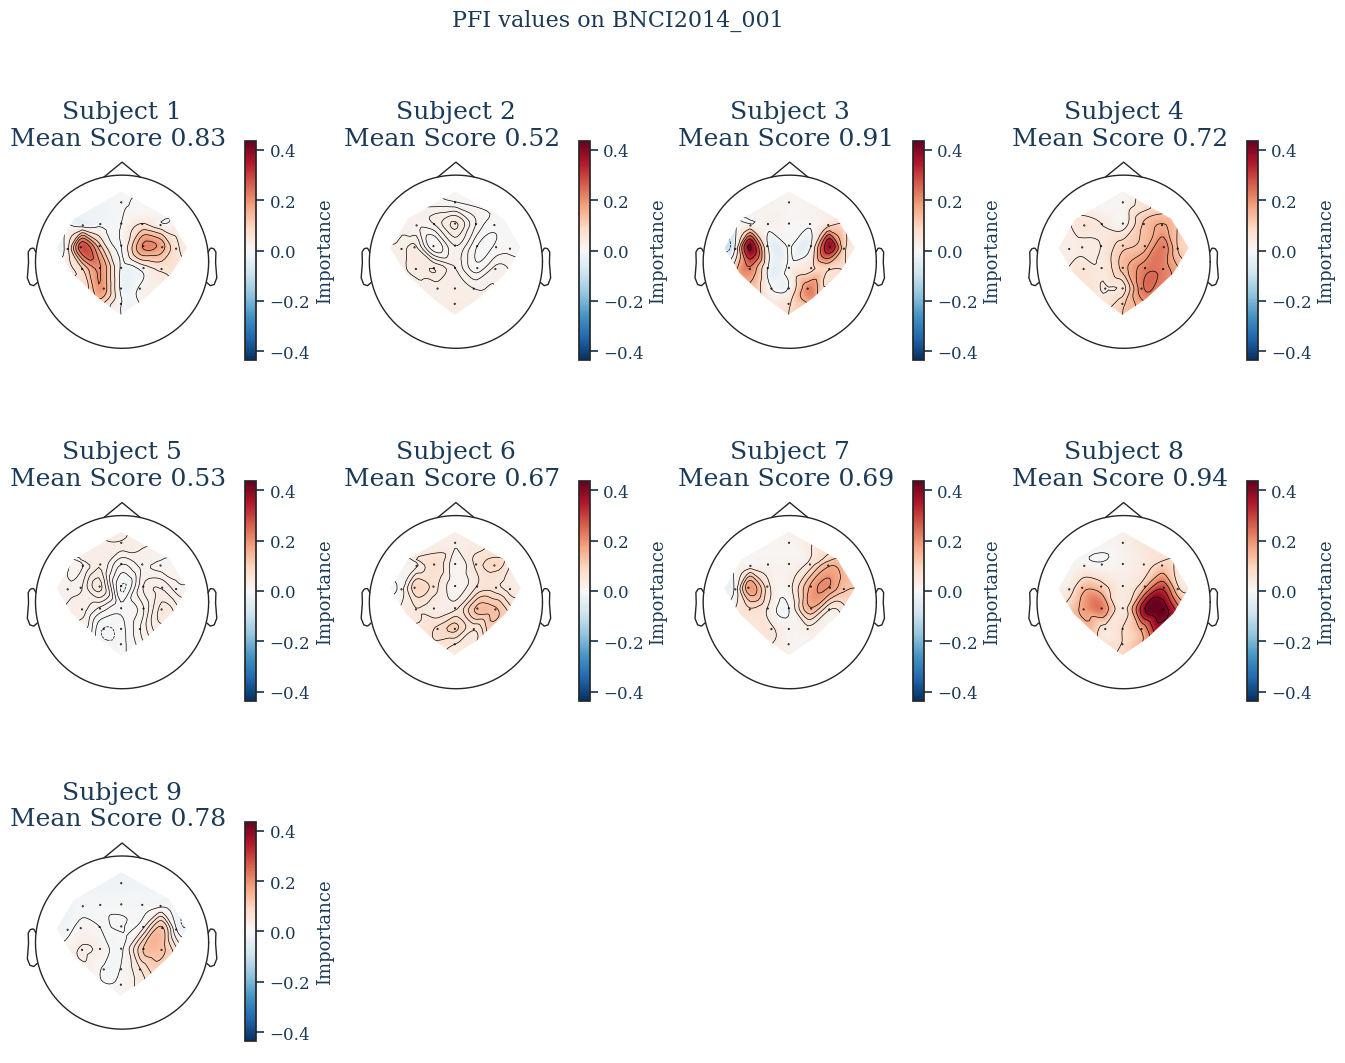

In [35]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_spd.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects_PFI_SPD_MDM.pdf')

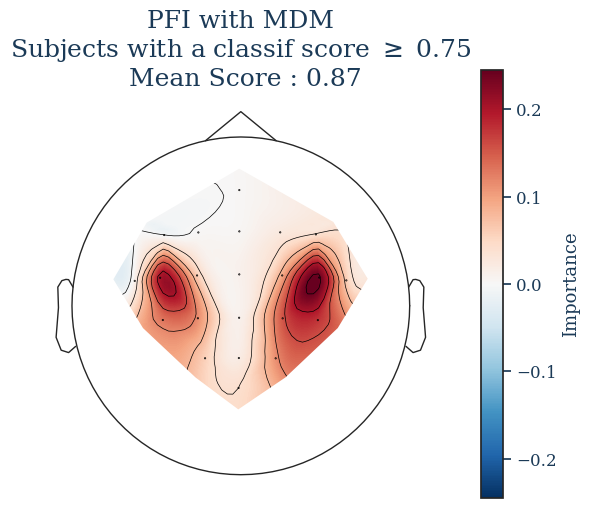

In [36]:
from src.data.utils import split_subjects_by_score, stack_subjects_by_field
high, low = split_subjects_by_score(results_spd)
importance_HP_subjects = stack_subjects_by_field(results_spd, high, field = "importance")
accuracy_HP_subjects = stack_subjects_by_field(results_spd, subject_names = high, field = "accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"PFI with MDM\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_MDM_SPD.pdf',
            cbar_type = "Permutation")


In [37]:
results_spd_ts_classif = compute_pfi_spd_for_subjects(data_spd, n_splits=10, classifier=TSClassifier)

Calculating importance for Subject 1...
Calculating importance for Subject 2...
Calculating importance for Subject 3...
Calculating importance for Subject 4...
Calculating importance for Subject 5...
Calculating importance for Subject 6...
Calculating importance for Subject 7...
Calculating importance for Subject 8...
Calculating importance for Subject 9...


In [38]:
importances_all_subjects = np.array([np.mean(results_spd_ts_classif[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_spd_ts_classif[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

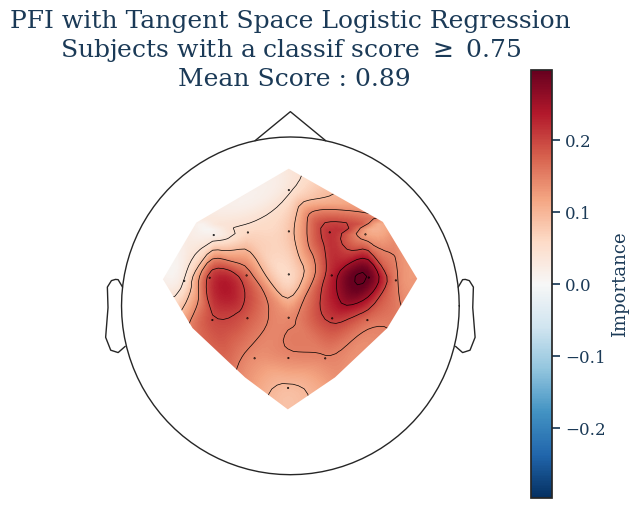

In [39]:
from src.data.utils import split_subjects_by_score, stack_subjects_by_field
high, low = split_subjects_by_score(results_spd_ts_classif)
importance_HP_subjects = stack_subjects_by_field(results_spd_ts_classif, high, field = "importance")
accuracy_HP_subjects = stack_subjects_by_field(results_spd_ts_classif, subject_names = high, field = "accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"PFI with Tangent Space Logistic Regression\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_PFI_TSClassifier.pdf',
            cbar_type = "Permutation")


In [40]:
deep_perm = DeepFeaturePermutationSPD()

In [41]:
from src.Permutation.multi_subjects import compute_deep_pfi_spd_for_subjects

results_spd_deep = compute_deep_pfi_spd_for_subjects(data_spd, n_splits=10, model_config=model_config, model_type=SPDNetBatchNorm)

Calculating importance for Subject 1...
Epoch 10/200 - Loss: 0.6903 - Test Acc: 0.6379
Epoch 20/200 - Loss: 0.6696 - Test Acc: 0.6897
Epoch 30/200 - Loss: 0.6481 - Test Acc: 0.7414
Epoch 40/200 - Loss: 0.6258 - Test Acc: 0.8966
Epoch 50/200 - Loss: 0.6043 - Test Acc: 0.8621
Epoch 60/200 - Loss: 0.5838 - Test Acc: 0.8966
Epoch 70/200 - Loss: 0.5643 - Test Acc: 0.8966
Epoch 80/200 - Loss: 0.5457 - Test Acc: 0.8966
Epoch 90/200 - Loss: 0.5281 - Test Acc: 0.8966
Epoch 100/200 - Loss: 0.5112 - Test Acc: 0.8966
Epoch 110/200 - Loss: 0.4950 - Test Acc: 0.8966
Epoch 120/200 - Loss: 0.4795 - Test Acc: 0.8966
Epoch 130/200 - Loss: 0.4648 - Test Acc: 0.8966
Epoch 140/200 - Loss: 0.4509 - Test Acc: 0.8966
Epoch 150/200 - Loss: 0.4378 - Test Acc: 0.8966
Epoch 160/200 - Loss: 0.4255 - Test Acc: 0.8966
Epoch 170/200 - Loss: 0.4138 - Test Acc: 0.8966
Epoch 180/200 - Loss: 0.4028 - Test Acc: 0.8793
Epoch 190/200 - Loss: 0.3923 - Test Acc: 0.8793
Epoch 200/200 - Loss: 0.3824 - Test Acc: 0.8793
Epoch 10/

In [42]:
importances_subject_1_deep = results_spd_deep["subject_1"]["importance"]

KeyError: 'subject_1'

In [ ]:
plot_topomap(np.mean(importances_subject_1_deep, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1_deep.pdf')

In [ ]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_spd_deep[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_spd_deep[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

In [ ]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_spd.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects_spd_deep.pdf')

In [ ]:
from src.data.utils import split_subjects_by_score, stack_subjects_by_field
high, low = split_subjects_by_score(results_eeg_deep)
importance_HP_subjects = stack_subjects_by_field(results_eeg_deep, high, field = "importance")
accuracy_HP_subjects = stack_subjects_by_field(results_eeg_deep, subject_names = high, field = "accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"PFI with SPDNet\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_SPDNet_SPD.pdf',
            cbar_type = "Permutation")


# Shapley values

## Exact version

This computation of the Shapley values is the one done in the paper but it takes a very long time to do so (hours per split for the 9 subjects of the BNCI2014_001 dataset)
It is only available for the SPD baseline

In [ ]:
from src.Shapley.Exact.multi_subjects import compute_exact_shapley_for_subjects

In [ ]:
RUN_EXACT_SHAPLEY = False  # Set to True to recompute the full experiment.

if RUN_EXACT_SHAPLEY:
    results_dic_shapley_exact = compute_exact_shapley_for_subjects(
        data_eeg, clf="TSClassifier"
    )

Since this computation is very long, the following demonstration loads precomputed Shapley values and scores. They were produced with the exact Shapley `fit` function and stored as `.npy` arrays. To compute the same results directly for a dictionary of subjects, use `compute_exact_shapley_for_subjects` from `src/Shapley/Exact/multi_subjects.py`.

In [ ]:
from src.data.utils import build_results_dict

shapley_values_MDM = np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/MDM/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_shap_values_MDM.npy")
shapley_values_scores = np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/MDM/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_scores_shapley_exact_MDM.npy")
results_exact_mdm = build_results_dict(
    data_eeg.keys(), shapley_values_MDM, shapley_values_scores
)

In [ ]:
high, low = split_subjects_by_score(results_exact_mdm, threshold=0.75)
print(high, low)

In [ ]:
importance_HP_subjects = stack_subjects_by_field(results_exact_mdm, high, field="importance", axis=(0, 1))
accuracy_HP_subjects = stack_subjects_by_field(results_exact_mdm, high, field="accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"Shapley values with MDM\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_Shapley_MDM.pdf',
            cbar_type = "Shapley")

In [ ]:
shapley_values_TSClassifier = np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/TSClassifier/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_shap_values_TSClassifier.npy")
shapley_values_scores = np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/TSClassifier/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_scores_shapley_exact_TSClassifier.npy")
results_exact_ts = build_results_dict(
    data_eeg.keys(), shapley_values_TSClassifier, shapley_values_scores
)

In [ ]:
high, low = split_subjects_by_score(results_exact_ts, threshold=0.75)
print(high, low)

In [ ]:
importance_HP_subjects = stack_subjects_by_field(results_exact_ts, high, field="importance", axis=(0, 1))
accuracy_HP_subjects = stack_subjects_by_field(results_exact_ts, high, field="accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"Shapley values with TS Logistic Regression\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_Shapley_TSClassifier.pdf',
            cbar_type = "Shapley")

In [ ]:
shapley_values_SPDNet = np.array(np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/SPDNet/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_shap_values.pkl", allow_pickle=True))
shapley_values_scores = np.load(PRECOMPUTED_RESULTS_DIR / "Shapley/SPDNet/BNCI2014_001/Shapley_SPD/Heuristic/Shapley_exhaustif/all_scores.npy")
results_exact_spdnet = build_results_dict(
    data_eeg.keys(), shapley_values_SPDNet, shapley_values_scores
)

In [ ]:
high, low = split_subjects_by_score(results_exact_spdnet, threshold=0.75)
print(high, low)

In [ ]:
importance_HP_subjects = stack_subjects_by_field(results_exact_spdnet, high, field="importance", axis=(0, 1))
accuracy_HP_subjects = stack_subjects_by_field(results_exact_spdnet, high, field="accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"Shapley values with SPDNet\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects_Shapley_SPDNet.pdf',
            cbar_type = "Shapley")

## Approximative versions with Kernel Shap

In [ ]:
from src.Shapley.ShapleyValuesEEG import ShapleyValuesEEG, DeepShapleyValuesEEG
from src.Shapley.multi_subjects import compute_kernel_shap_spd_for_subjects

The EEG version can be called thanks to `compute_kernel_shap_eeg_for_subjects`or `compute_deep_kernel_shap_eeg_for_subjects` for deep models. is ca
The SPD version is called with `compute_kernel_shap_spd_for_subjects` or `compute_deep_kernel_shap_spd_for_subjects`and only takes spd matrices as input. 

In [ ]:
shapley_approximate_spd = compute_kernel_shap_spd_for_subjects(data_spd, n_splits=1, classifier=MDM())

In [ ]:
shapley_all_subjects = np.array([np.mean(shapley_approximate_spd[f'Subject {i}']["importance"], axis=(0, 1)) for i in range(1, 10)])
scores_all_subjects = np.array([np.mean(shapley_approximate_spd[f'Subject {i}']["accuracy"], axis=0) for i in range(1, 10)])

In [ ]:
print(shapley_all_subjects.shape)

In [ ]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(shapley_all_subjects, list(data_spd.keys()), sensors, scores_all_subjects, suptitle = "Shapley values on BNCI2014_001", cbar_type = 'Shapley', savefile_path = DATA_DIR+'topomap_all_subjects_shapley_spd_mdm.pdf')

# Agreement between attribution rankings

The agreement between two channel-importance methods is evaluated with different complementary metrics: Spearman correlation measures global rank agreement, top-k overlap reports the proportion of shared channels among the k highest-ranked channels, Kendall Tau compares the number of pairs that have the same order of ranking and Weighted Kendall Tau does the same with more weight given to the top pairs. Weighted Kendall Tau is often considered a balanced rank similarity metric and it is the one reported in the article. 

For signed attributions, `rank_by="value"` preserves class direction whereas `rank_by="magnitude"` compares attribution strength independently of direction. The latter is used below to compare PFI and Shapley values.

In [ ]:
from src.Interpretability import compare_rankings

subject_name = "Subject 1"
pfi_importance = np.mean(results_spd[subject_name]["importance"], axis=0)
shapley_importance = np.mean(
    np.asarray(shapley_approximate_spd[subject_name]["importance"]),
    axis=(0, 1),
)

agreement = compare_rankings(
    pfi_importance,
    shapley_importance,
    channel_names=sensors,
    k=5,
    rank_by="magnitude",
)
agreement

# Trial-level Shapley distributions

A topomap summarizes the average attribution of each channel, but it does not show how attributions vary between trials. The following beeswarm-style plot displays one point per trial and channel. Channels are ordered by decreasing mean absolute Shapley value. This visualization is a distribution plot; unlike the standard SHAP beeswarm, point color does not encode the original feature value.

In [ ]:
from src.Visualization.beeswarm import shap_beeswarm

subject_shapley = np.asarray(
    shapley_approximate_spd[subject_name]["importance"]
)[0]  # first split: (n_trials, n_channels)

fig, ax = shap_beeswarm(
    subject_shapley,
    sensor_names=sensors,
    subject=subject_name,
    max_channels=10,
)